# Assignment 1

**Sinh viên:** Lưu Anh Dũng  
**Mã sinh viên:** B23DCDK036

# 1. Introduction

This assignment presents a small clinical decision-support system for early diabetes screening using routine physiological and demographic measurements from the Pima Indians Diabetes dataset. Diabetes is a major public health concern, and early detection is crucial for preventing severe long-term complications. The goal of this project is to build a complete end-to-end machine learning pipeline: formulating the diagnostic task as a binary classification problem, handling data preprocessing and feature representation, evaluating and comparing several classical machine learning models, and finally deploying the best-performing classifier into an interactive demo application.

# 2. Intelligent System Definition

This system acts as a clinical decision-support tool for the early triage of patients at risk of diabetes. It looks at a patient's demographic and clinical measurements and returns a prediction, which a healthcare professional can use to decide who needs closer follow-up.

**System characteristics:**
1. **Real-world problem.** Diabetes is easier to manage the earlier it is caught. The system uses routine clinical measurements that are already collected during a checkup to flag patients who may be at higher risk, before more serious complications develop.
2. **System input.** The environment gives the system a patient's age together with seven clinical measurements: Pregnancies, Glucose, Blood Pressure, Skin Thickness, Insulin, BMI, and Diabetes Pedigree Function.
3. **Internal representation.** These raw values are represented internally as an 8-dimensional numerical feature vector. Missing or physiologically impossible zero readings are filled in using statistics from the training data, and the vector is standardized when the learning algorithm is distance-based.
4. **Learning objective.** The model learns a decision boundary that maps this 8-dimensional representation to the diagnostic outcomes observed in the training data.
5. **System output.** The system returns a binary decision — diabetic (1) or non-diabetic (0) — along with a probability estimate of the risk.
6. **Application context.** The intended users are clinicians doing an initial screening, and patients using the companion demo app to get a rough sense of their own risk.

**Formal problem statement:** *Given an 8-dimensional feature vector describing a patient's clinical profile, predict whether that patient is diabetic or non-diabetic.*

**Pipeline diagram:**
```mermaid
flowchart LR
    A[Environment:\nRaw Patient\nMedical Data] --> B[Input Representation:\nFeature Vector]
    B --> C[Learning / Model:\nTrained ML\nClassifier]
    C --> D[Decision / Output:\nBinary Prediction]
```

# 3. Problem Definition

**Learning task.** Supervised binary classification. The goal is to learn a function $f_\theta(x)$ that predicts whether `Outcome` is 1 (diabetic) or 0 (non-diabetic) given a patient's feature vector.

**Feature space.** $x \in \mathbb{R}^8$, made up of eight numerical features: Pregnancies, Glucose, BloodPressure, SkinThickness, Insulin, BMI, DiabetesPedigreeFunction, and Age.

**Target output.** $\hat{y} \in \{0, 1\}$, the predicted class, together with a class probability so results can be used for risk-based triage rather than a hard yes/no.

**Formal problem statement:** Given an 8-dimensional feature vector describing a patient's clinical profile, predict whether that patient is diabetic or non-diabetic.

# 4. Dataset

- **Dataset Source:** Kaggle — Diabetes Dataset ([hasibur013/diabetes-dataset](https://www.kaggle.com/datasets/hasibur013/diabetes-dataset))
- **What real-world phenomenon is represented?** Clinical, demographic, and physiological risk factors influencing the onset of diabetes among adult female patients of Pima Indian heritage.
- **What is one observation?** An individual patient record containing a cross-sectional set of diagnostic measurements collected during a single medical checkup.
- **What are the features?** `Pregnancies`, `Glucose`, `BloodPressure`, `SkinThickness`, `Insulin`, `BMI`, `DiabetesPedigreeFunction`, and `Age`.
- **What is the target?** `Outcome` (clinical diagnosis: 1 for diabetic, 0 for non-diabetic).
- **Is the target numerical or categorical?** Categorical (binary).
- **Is this regression or classification?** Supervised binary classification.
- **How many observations are available?** 768 patient samples.
- **How many features are available?** 8 input predictor variables.
- **Which features are numerical?** All 8 input features — a combination of continuous medical readings and discrete counts.
- **Which features are categorical?** None of the input predictor features; only the target variable `Outcome` is categorical.

## Dataset Preview

Below is a quick look at the raw dataset: the first few records, the full descriptive statistics, and the data types for each column.

In [1]:
import pandas as pd

df_raw = pd.read_csv("diabetes.csv")
df_raw.columns = df_raw.columns.str.strip()

print(f"Dataset shape: {df_raw.shape[0]} rows × {df_raw.shape[1]} columns")
print()
print("=== First 5 rows ===")
display(df_raw.head())

Dataset shape: 768 rows × 9 columns

=== First 5 rows ===


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72.0,35,169.5,33.6,0.627,50,1
1,1,85,66.0,29,102.5,26.6,0.351,31,0
2,8,183,64.0,32,169.5,23.3,0.672,32,1
3,1,89,66.0,23,94.0,28.1,0.167,21,0
4,0,137,40.0,35,168.0,43.1,2.288,33,1


In [2]:
print("=== Descriptive Statistics ===")
display(df_raw.describe().round(3))

=== Descriptive Statistics ===


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000,768.000,768.000,768.000,768.000,768.000,768.000,768.000,768.000
mean,3.845,121.677,72.389,29.090,141.754,32.435,0.472,33.241,0.349
std,3.370,30.464,12.106,8.891,89.101,6.880,0.331,11.760,0.477
min,0.000,44.000,24.000,7.000,14.000,18.200,0.078,21.000,0.000
25%,1.000,99.750,64.000,25.000,102.500,27.500,0.244,24.000,0.000
50%,3.000,117.000,72.000,28.000,102.500,32.050,0.372,29.000,0.000
75%,6.000,140.250,80.000,32.000,169.500,36.600,0.626,41.000,1.000
max,17.000,199.000,122.000,99.000,846.000,67.100,2.420,81.000,1.000


In [3]:
print("=== Column Info ===")
df_raw.info()
print()
print("=== Missing / Zero Value Counts ===")
zero_cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
zero_counts = (df_raw[zero_cols] == 0).sum().rename("Zero count")
zero_pct = ((df_raw[zero_cols] == 0).mean() * 100).rename("Zero %").round(1)
display(pd.concat([zero_counts, zero_pct], axis=1))

=== Column Info ===
<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    float64
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    float64
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(4), int64(5)
memory usage: 54.1 KB

=== Missing / Zero Value Counts ===


,Zero count,Zero %
Glucose,0,0.0
BloodPressure,0,0.0
SkinThickness,0,0.0
Insulin,0,0.0
BMI,0,0.0


# 5. Data Representation

A patient's clinical profile is represented as an 8-dimensional numerical feature vector: $x_i = [x_{i1}, x_{i2}, \dots, x_{i8}] \in \mathbb{R}^8$.

| Feature | Type | Representation | Meaning |
| :--- | :--- | :--- | :--- |
| Pregnancies | Numerical | Integer | Number of pregnancies |
| Glucose | Numerical | Real value | Plasma glucose concentration |
| BloodPressure | Numerical | Real value | Diastolic blood pressure (mm Hg) |
| SkinThickness | Numerical | Real value | Triceps skin-fold thickness (mm) |
| Insulin | Numerical | Real value | 2-hour serum insulin (mu U/ml) |
| BMI | Numerical | Real value | Body mass index |
| DiabetesPedigreeFunction | Numerical | Real value | Pedigree-based diabetes likelihood score |
| Age | Numerical | Integer | Age in years |

## Feature Analysis & Preprocessing

All 8 input features are numerical, while the target variable `Outcome` is binary categorical (1 for diabetic, 0 for non-diabetic). The raw input features operate on significantly different numerical scales—for instance, `DiabetesPedigreeFunction` values are typically below 3.0, whereas `Insulin` measurements can reach into the hundreds. Additionally, several continuous clinical fields contain physiologically invalid zero readings (such as zero `Glucose` or zero `BMI`), indicating missing patient data.

To address these data properties, a two-step preprocessing pipeline is applied:
1. **Missing Data Imputation:** Physiologically invalid zero values in continuous clinical measurements are treated as missing data and imputed using median statistics calculated strictly from the training split.
2. **Feature Standardization:** Input features are transformed to zero mean and unit variance ($z = \frac{x - \mu}{\sigma}$). This prevents high-magnitude features (like `Insulin`) from dominating distance-based algorithms (such as k-NN and SVM), ensuring balanced feature influence across all models.

# 6. Traditional ML Methods

This section outlines the machine learning models trained for this assignment. Starting with a dummy baseline, we evaluate six classical classifiers tuned using grid search.

## 1. Logistic Regression
- **What representation does it receive?** Scaled 8-dimensional feature vector ($x \in \mathbb{R}^8$).
- **What relationship does it try to learn?** A linear boundary separating diabetic and non-diabetic cases.
- **What parameters or structures are learned?** A weight vector $w$ (one weight per feature) and a bias term $b$.
- **What criterion guides learning?** Minimizing binary cross-entropy loss (maximizing probability likelihood).
- **What assumptions does the model make?** A linear boundary is sufficient to separate classes, and features are not highly correlated.
- **What are its strengths?** Very fast, easy to interpret (weights show feature impact), outputs clear probability scores.
- **What are its weaknesses?** Struggles when relationships are non-linear or features interact heavily.

## 2. Support Vector Machine (Linear Kernel)
- **What representation does it receive?** Scaled 8-dimensional feature vector ($x \in \mathbb{R}^8$).
- **What relationship does it try to learn?** The optimal straight hyperplane that maximizes the gap between the two classes.
- **What parameters or structures are learned?** Weights, bias, and the support vectors defining the boundary margin.
- **What criterion guides learning?** Maximizing the margin size while penalizing classification errors (regularization parameter C).
- **What assumptions does the model make?** The classes are linearly separable (or close to it).
- **What are its strengths?** Robust against outliers outside the margin, highly effective in high dimensions.
- **What are its weaknesses?** Cannot model non-linear boundaries natively; highly sensitive to feature scaling.

## 3. Support Vector Machine (RBF Kernel)
- **What representation does it receive?** Scaled 8-dimensional feature vector ($x \in \mathbb{R}^8$).
- **What relationship does it try to learn?** A non-linear decision boundary by implicitly projecting the data into a higher-dimensional space.
- **What parameters or structures are learned?** Support vectors, dual coefficients (weights), and kernel parameter gamma (defines feature similarity range).
- **What criterion guides learning?** Maximizing the margin in the kernel-projected space.
- **What assumptions does the model make?** Patients with similar clinical values (defined by RBF distance) share the same diagnosis.
- **What are its strengths?** Highly flexible; can map complex, curved decision boundaries.
- **What are its weaknesses?** Hard to interpret; tuning parameters ($C$ and $\gamma$) requires careful grid search.

## 4. k-Nearest Neighbors (k-NN)
- **What representation does it receive?** Scaled 8-dimensional feature vector ($x \in \mathbb{R}^8$).
- **What relationship does it try to learn?** Local geometric similarity: patients with similar clinical features should have similar diagnostic labels.
- **What parameters or structures are learned?** None (it is a non-parametric model that just memorizes the training data).
- **What criterion guides learning?** Majority voting among the $k$ closest neighbors using Euclidean distance.
- **What assumptions does the model make?** Patients close to each other in feature space are likely to have the same outcome.
- **What are its strengths?** Very simple to understand, requires no explicit training phase.
- **What are its weaknesses?** Slow prediction speed (must calculate distance to all training points); highly sensitive to scaling and noisy data.

## 5. Random Forest
- **What representation does it receive?** 8-dimensional feature vector ($x \in \mathbb{R}^8$).
- **What relationship does it try to learn?** Complex, non-linear decision boundaries through multiple branching decision trees.
- **What parameters or structures are learned?** An ensemble of independent decision trees split on feature thresholds.
- **What criterion guides learning?** Minimizing Gini impurity or entropy at each tree split across bootstrapped data.
- **What assumptions does the model make?** Averaging predictions from many uncorrelated trees cancels out individual errors (lowers variance).
- **What are its strengths?** Excellent accuracy, handles non-linear patterns and feature interactions automatically, robust to outliers.
- **What are its weaknesses?** Hard to interpret (black-box model); can be slow and resource-heavy with many trees.

## 6. XGBoost (Extreme Gradient Boosting)
- **What representation does it receive?** 8-dimensional feature vector ($x \in \mathbb{R}^8$).
- **What relationship does it try to learn?** High-performance non-linear boundaries by building trees sequentially to correct prior errors.
- **What parameters or structures are learned?** A sequence of boosting trees and leaf node weights.
- **What criterion guides learning?** Minimizing a regularized loss function using gradient descent optimization.
- **What assumptions does the model make?** Adding weak learners sequentially to minimize errors iteratively yields the best predictor.
- **What are its strengths?** State-of-the-art predictive power on tabular data, built-in regularization, fast runtimes.
- **What are its weaknesses?** Prone to overfitting if hyperparameters (learning rate, max depth) are not tuned carefully.

## 7. Baseline (Dummy Classifier)
- **What representation does it receive?** Training target class distribution (ignores patient features).
- **What relationship does it try to learn?** None; simply predicts the most frequent class.
- **What parameters or structures are learned?** Training label frequency statistics.
- **What criterion guides learning?** Predicting the majority class (Non-Diabetic).
- **What assumptions does the model make?** The class distribution in the dataset is the only reliable predictor.
- **What are its strengths?** Extremely simple benchmark to ensure other models are actually learning something.
- **What are its weaknesses?** Zero actual predictive capability.

# 7. Experimental Design

The dataset is split into training and test sets with an 80/20 ratio, using stratified sampling on `Outcome` so both sets keep roughly the same class balance.

This split happens before any imputation or scaling. All preprocessing statistics — the median used for imputation, the mean and variance used for standardization — are computed only from the training set, then applied to both training and test sets. Doing it in this order keeps the test set genuinely unseen during preprocessing and avoids leaking any information from it into training.

In [4]:
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# Silence noisy-but-benign library warnings (e.g. the baseline's undefined
# precision on a class it never predicts, and sklearn's SVC `probability`
# deprecation notice) so the report output stays focused on real results.
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, auc,
)

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb

sns.set_theme(style="whitegrid", palette="deep")

# 1. Load the raw clinical records
df = pd.read_csv("diabetes.csv")
df.columns = df.columns.str.strip()

# 2. Split off the test set BEFORE any imputation/scaling statistic is
#    computed, so nothing about it can bias preprocessing decisions.
X = df.drop('Outcome', axis=1)
y = df['Outcome']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
X_train, X_test = X_train.copy(), X_test.copy()

# 3. Treat physiologically-invalid zeros as missing, then impute using
#    statistics learned from the TRAINING split only.
cols_to_impute = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
X_train[cols_to_impute] = X_train[cols_to_impute].replace(0, np.nan)
X_test[cols_to_impute] = X_test[cols_to_impute].replace(0, np.nan)

imputer = SimpleImputer(strategy='median')
X_train[cols_to_impute] = imputer.fit_transform(X_train[cols_to_impute])
X_test[cols_to_impute] = imputer.transform(X_test[cols_to_impute])
joblib.dump(imputer, 'imputer.pkl')

# 4. Feature scaling (fit on the training split only)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
joblib.dump(scaler, 'scaler.pkl')

# 5. Shared bookkeeping and a reusable scoring/plotting helper for every
#    model trained below.
model_metrics = []
model_filenames = {}
model_needs_scaling = {}
model_objects = {}


def evaluate_model(name, model, X_te, y_te, filename, needs_scaling):
    """Score a fitted model, log it for the comparison table in Section 9,
    persist it to disk, and render its confusion matrix."""
    y_pred = model.predict(X_te)
    acc = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred, zero_division=0)
    rec = recall_score(y_te, y_pred, zero_division=0)
    f1 = f1_score(y_te, y_pred, zero_division=0)

    model_metrics.append({'Model': name, 'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1': f1})
    model_filenames[name] = filename
    model_needs_scaling[name] = needs_scaling
    model_objects[name] = model
    joblib.dump(model, filename)

    print(f"Accuracy: {acc*100:.2f}% | Precision: {prec:.3f} | Recall: {rec:.3f} | F1: {f1:.3f}")
    print(classification_report(y_te, y_pred, target_names=['Non-Diabetic', 'Diabetic']))

    cm = confusion_matrix(y_te, y_pred)
    cm_pct = cm / cm.sum() * 100
    labels = np.array([f"{count}\n({pct:.1f}%)" for count, pct in zip(cm.flatten(), cm_pct.flatten())]).reshape(cm.shape)
    plt.figure(figsize=(4.5, 4))
    sns.heatmap(cm, annot=labels, fmt='', cmap='YlGnBu', cbar=False,
                xticklabels=['Non-Diabetic', 'Diabetic'], yticklabels=['Non-Diabetic', 'Diabetic'])
    plt.title(f'{name} — Confusion Matrix')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.tight_layout()
    plt.show()
    return y_pred


# 8. Results

This section reports what happened when each model was trained and evaluated: the baseline and the six tuned classifiers from Section 6, an exploratory look at the data itself, and a closer look at how sensitive k-NN is to its hyperparameters.

## Evaluation Protocol

Every trained model, including the baseline, is scored on the test set using Accuracy, Precision, Recall, F1-score, and a confusion matrix.

In a screening context, **Recall** matters most: missing an actual diabetic patient (a false negative) is a far more costly mistake than flagging a healthy patient for a second look (a false positive). The dataset is also moderately imbalanced toward non-diabetic cases, so Accuracy on its own can be misleading. For this reason, the **F1-score** — which balances Precision and Recall — is used as the main metric for comparing models and picking the final one.

## Baseline

A `DummyClassifier` using the `most_frequent` strategy provides the baseline.

**Why bother with a baseline?** It shows what "no real learning at all" looks like, so it's possible to check that the trained models are actually picking up a useful signal from the data rather than just reflecting the class imbalance. Any model that can't beat this baseline isn't learning anything useful.

Accuracy: 64.94% | Precision: 0.000 | Recall: 0.000 | F1: 0.000
              precision    recall  f1-score   support

Non-Diabetic       0.65      1.00      0.79       100
    Diabetic       0.00      0.00      0.00        54

    accuracy                           0.65       154
   macro avg       0.32      0.50      0.39       154
weighted avg       0.42      0.65      0.51       154



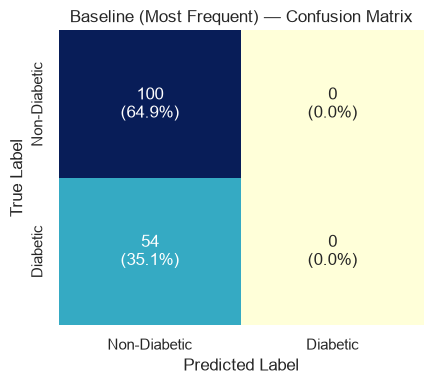

In [5]:
from sklearn.dummy import DummyClassifier

dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train, y_train)
y_pred_dummy = evaluate_model('Baseline (Most Frequent)', dummy, X_test, y_test, 'baseline.pkl', needs_scaling=False)


## Model 1: Logistic Regression


Best hyperparameters: {'C': 0.1}
Accuracy: 70.78% | Precision: 0.588 | Recall: 0.556 | F1: 0.571
              precision    recall  f1-score   support

Non-Diabetic       0.77      0.79      0.78       100
    Diabetic       0.59      0.56      0.57        54

    accuracy                           0.71       154
   macro avg       0.68      0.67      0.67       154
weighted avg       0.70      0.71      0.71       154



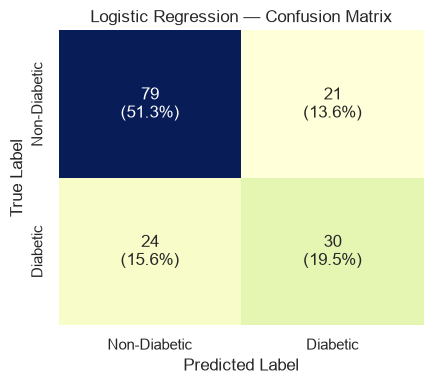

In [6]:
param_grid_lr = {'C': [0.01, 0.1, 1, 10, 100]}
grid_lr = GridSearchCV(LogisticRegression(random_state=42, max_iter=1000), param_grid_lr, cv=5, scoring='accuracy')
grid_lr.fit(X_train_scaled, y_train)
best_lr = grid_lr.best_estimator_
print(f"Best hyperparameters: {grid_lr.best_params_}")

y_pred_lr = evaluate_model('Logistic Regression', best_lr, X_test_scaled, y_test, 'logistic_regression.pkl', needs_scaling=True)


## Model 2: SVM (Linear)


Best hyperparameters: {'C': 1}
Accuracy: 74.03% | Precision: 0.630 | Recall: 0.630 | F1: 0.630
              precision    recall  f1-score   support

Non-Diabetic       0.80      0.80      0.80       100
    Diabetic       0.63      0.63      0.63        54

    accuracy                           0.74       154
   macro avg       0.71      0.71      0.71       154
weighted avg       0.74      0.74      0.74       154



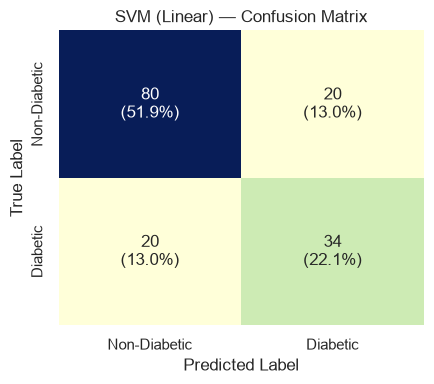

In [7]:
param_grid_svml = {'C': [0.01, 0.1, 1, 10]}
grid_svml = GridSearchCV(SVC(kernel='linear', random_state=42, probability=True), param_grid_svml, cv=5, scoring='accuracy')
grid_svml.fit(X_train_scaled, y_train)
best_svml = grid_svml.best_estimator_
print(f"Best hyperparameters: {grid_svml.best_params_}")

y_pred_svml = evaluate_model('SVM (Linear)', best_svml, X_test_scaled, y_test, 'svm_linear.pkl', needs_scaling=True)


## Model 3: SVM (RBF)


Best hyperparameters: {'C': 1, 'gamma': 0.1}
Accuracy: 83.77% | Precision: 0.754 | Recall: 0.796 | F1: 0.775
              precision    recall  f1-score   support

Non-Diabetic       0.89      0.86      0.87       100
    Diabetic       0.75      0.80      0.77        54

    accuracy                           0.84       154
   macro avg       0.82      0.83      0.82       154
weighted avg       0.84      0.84      0.84       154



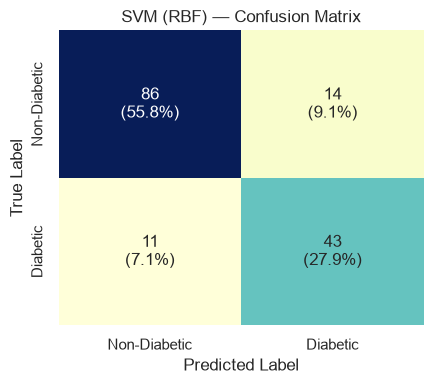

In [8]:
param_grid_svmr = {'C': [0.1, 1, 10], 'gamma': ['scale', 'auto', 0.01, 0.1]}
grid_svmr = GridSearchCV(SVC(kernel='rbf', random_state=42, probability=True), param_grid_svmr, cv=5, scoring='accuracy')
grid_svmr.fit(X_train_scaled, y_train)
best_svmr = grid_svmr.best_estimator_
print(f"Best hyperparameters: {grid_svmr.best_params_}")

y_pred_svmr = evaluate_model('SVM (RBF)', best_svmr, X_test_scaled, y_test, 'svm_rbf.pkl', needs_scaling=True)


## Model 4: KNN


Best hyperparameters: {'n_neighbors': 7, 'weights': 'uniform'}
Accuracy: 80.52% | Precision: 0.722 | Recall: 0.722 | F1: 0.722
              precision    recall  f1-score   support

Non-Diabetic       0.85      0.85      0.85       100
    Diabetic       0.72      0.72      0.72        54

    accuracy                           0.81       154
   macro avg       0.79      0.79      0.79       154
weighted avg       0.81      0.81      0.81       154



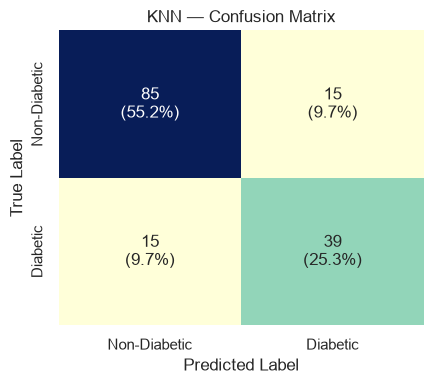

In [9]:
param_grid_knn = {'n_neighbors': [3, 5, 7, 9], 'weights': ['uniform', 'distance']}
grid_knn = GridSearchCV(KNeighborsClassifier(), param_grid_knn, cv=5, scoring='accuracy')
grid_knn.fit(X_train_scaled, y_train)
best_knn = grid_knn.best_estimator_
print(f"Best hyperparameters: {grid_knn.best_params_}")

y_pred_knn = evaluate_model('KNN', best_knn, X_test_scaled, y_test, 'knn.pkl', needs_scaling=True)


## Model 5: Random Forest


Best hyperparameters: {'max_depth': 10, 'n_estimators': 200}
Accuracy: 86.36% | Precision: 0.811 | Recall: 0.796 | F1: 0.804
              precision    recall  f1-score   support

Non-Diabetic       0.89      0.90      0.90       100
    Diabetic       0.81      0.80      0.80        54

    accuracy                           0.86       154
   macro avg       0.85      0.85      0.85       154
weighted avg       0.86      0.86      0.86       154



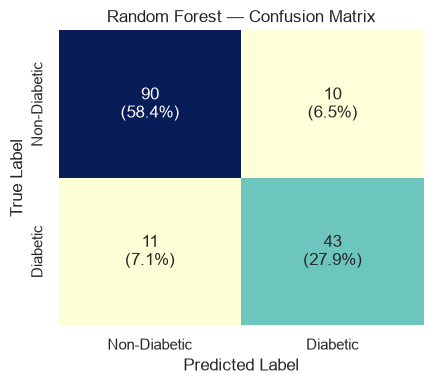

In [10]:
param_grid_rf = {'n_estimators': [50, 100, 200], 'max_depth': [None, 5, 10]}
grid_rf = GridSearchCV(RandomForestClassifier(random_state=42), param_grid_rf, cv=5, scoring='accuracy')
grid_rf.fit(X_train, y_train)
best_rf = grid_rf.best_estimator_
print(f"Best hyperparameters: {grid_rf.best_params_}")

y_pred_rf = evaluate_model('Random Forest', best_rf, X_test, y_test, 'random_forest.pkl', needs_scaling=False)


## Model 6: XGBoost


Best hyperparameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 50}
Accuracy: 87.66% | Precision: 0.818 | Recall: 0.833 | F1: 0.826
              precision    recall  f1-score   support

Non-Diabetic       0.91      0.90      0.90       100
    Diabetic       0.82      0.83      0.83        54

    accuracy                           0.88       154
   macro avg       0.86      0.87      0.87       154
weighted avg       0.88      0.88      0.88       154



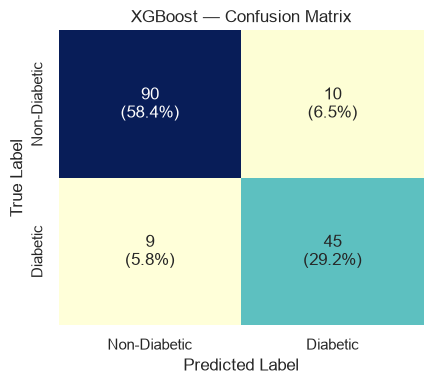

In [11]:
param_grid_xgb = {'n_estimators': [50, 100, 200], 'learning_rate': [0.01, 0.1, 0.2], 'max_depth': [3, 5]}
grid_xgb = GridSearchCV(xgb.XGBClassifier(eval_metric='logloss', random_state=42), param_grid_xgb, cv=5, scoring='accuracy')
grid_xgb.fit(X_train, y_train)
best_xgb = grid_xgb.best_estimator_
print(f"Best hyperparameters: {grid_xgb.best_params_}")

y_pred_xgb = evaluate_model('XGBoost', best_xgb, X_test, y_test, 'xgboost.pkl', needs_scaling=False)


## Performance Summary of Evaluated Models

To compare the models trained in this section, the following table summarizes the evaluation metrics (Accuracy, Precision, Recall, and F1-score) on the test set, sorted by the F1-score:

In [12]:
import pandas as pd
results_df = pd.DataFrame(model_metrics)
results_df_display = results_df.copy()
results_df_display["Accuracy"] = results_df_display["Accuracy"] * 100
results_df_display = results_df_display.sort_values(by="F1", ascending=False).reset_index(drop=True)

display(results_df_display.style.format({
    "Accuracy": "{:.2f}%", "Precision": "{:.3f}", "Recall": "{:.3f}", "F1": "{:.3f}"
}))

,Model,Accuracy,Precision,Recall,F1
0,XGBoost,87.66%,0.818,0.833,0.826
1,Random Forest,86.36%,0.811,0.796,0.804
2,SVM (RBF),83.77%,0.754,0.796,0.775
3,KNN,80.52%,0.722,0.722,0.722
4,SVM (Linear),74.03%,0.630,0.630,0.630
5,Logistic Regression,70.78%,0.588,0.556,0.571
6,Baseline (Most Frequent),64.94%,0.000,0.000,0.000


## Exploratory Data Analysis

Before looking at model outputs, it's worth understanding the data itself — how the features are distributed, how they relate to each other, and how they differ between diabetic and non-diabetic patients.

In [13]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("diabetes.csv")
df.columns = df.columns.str.strip()

display(df.head())
df.info()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72.0,35,169.5,33.6,0.627,50,1
1,1,85,66.0,29,102.5,26.6,0.351,31,0
2,8,183,64.0,32,169.5,23.3,0.672,32,1
3,1,89,66.0,23,94.0,28.1,0.167,21,0
4,0,137,40.0,35,168.0,43.1,2.288,33,1


<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    float64
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    float64
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(4), int64(5)
memory usage: 54.1 KB


### Feature Correlation Structure
- **Visualization:** A heatmap detailing the Pearson correlation coefficients across all numeric features.
- **Analytical Purpose:** This analysis identifies multicollinearity and highlights features that exhibit strong linear relationships with the target variable, providing insight into the predictive signals available to the models.


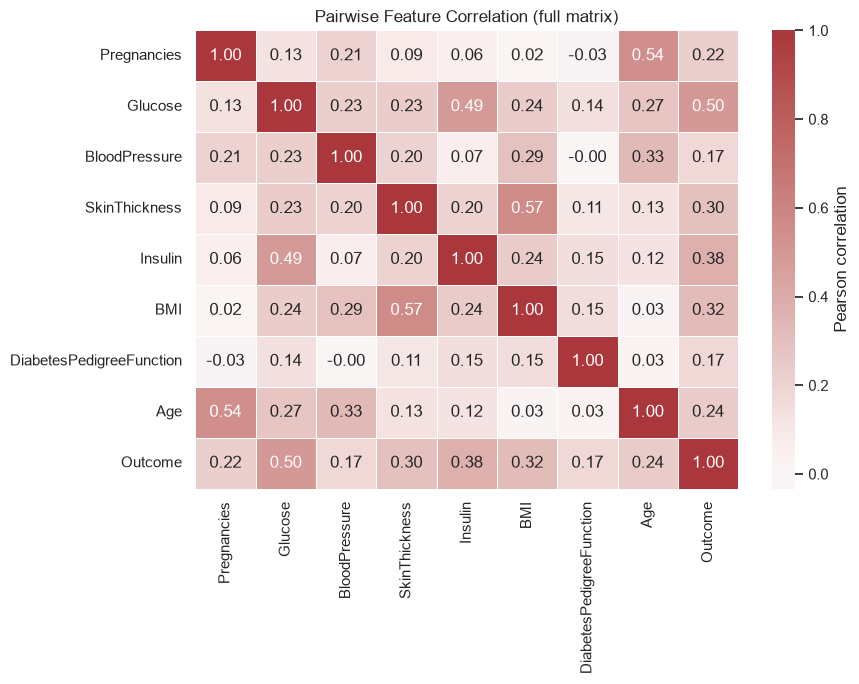

In [14]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='vlag', center=0,
            linewidths=0.5, cbar_kws={'label': 'Pearson correlation'})
plt.title('Pairwise Feature Correlation (full matrix)')
plt.tight_layout()
plt.show()

### Correlation with the Target Variable
- **Visualization:** A ranked bar chart of Pearson correlation coefficients between individual features and the `Outcome`.
- **Analytical Purpose:** This provides a clear, univariate ranking of feature importance based on linear association with the diagnostic outcome.


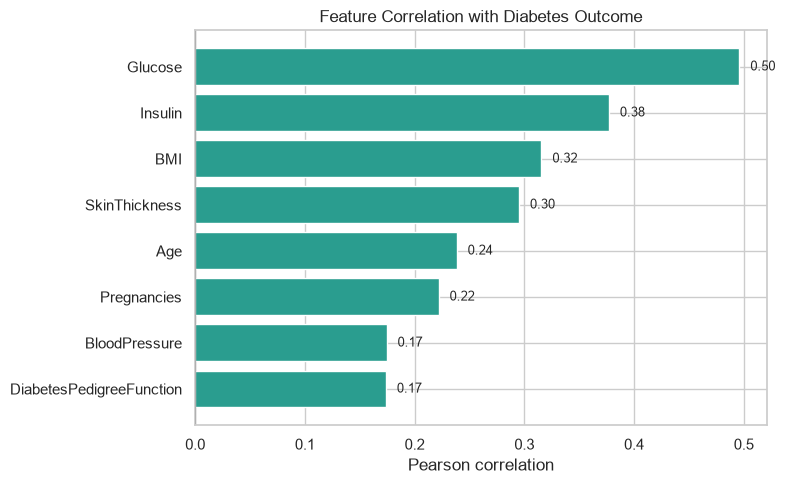

In [15]:
outcome_corr = df.corr(numeric_only=True)['Outcome'].drop('Outcome').sort_values()
colors = ['#c1121f' if v < 0 else '#2a9d8f' for v in outcome_corr.values]

plt.figure(figsize=(8, 5))
bars = plt.barh(outcome_corr.index, outcome_corr.values, color=colors)
for bar, v in zip(bars, outcome_corr.values):
    plt.text(v + (0.01 if v >= 0 else -0.01), bar.get_y() + bar.get_height() / 2,
              f"{v:.2f}", va='center', ha='left' if v >= 0 else 'right', fontsize=9)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Feature Correlation with Diabetes Outcome')
plt.xlabel('Pearson correlation')
plt.tight_layout()
plt.show()


### Pairwise Feature Relationships
- **Visualization:** A pairwise scatterplot matrix for key predictors (Glucose, BMI, Age, and Insulin), segregated by class outcome.
- **Analytical Purpose:** This multidimensional view helps identify complex, non-linear class separations that may not be apparent in univariate analyses.


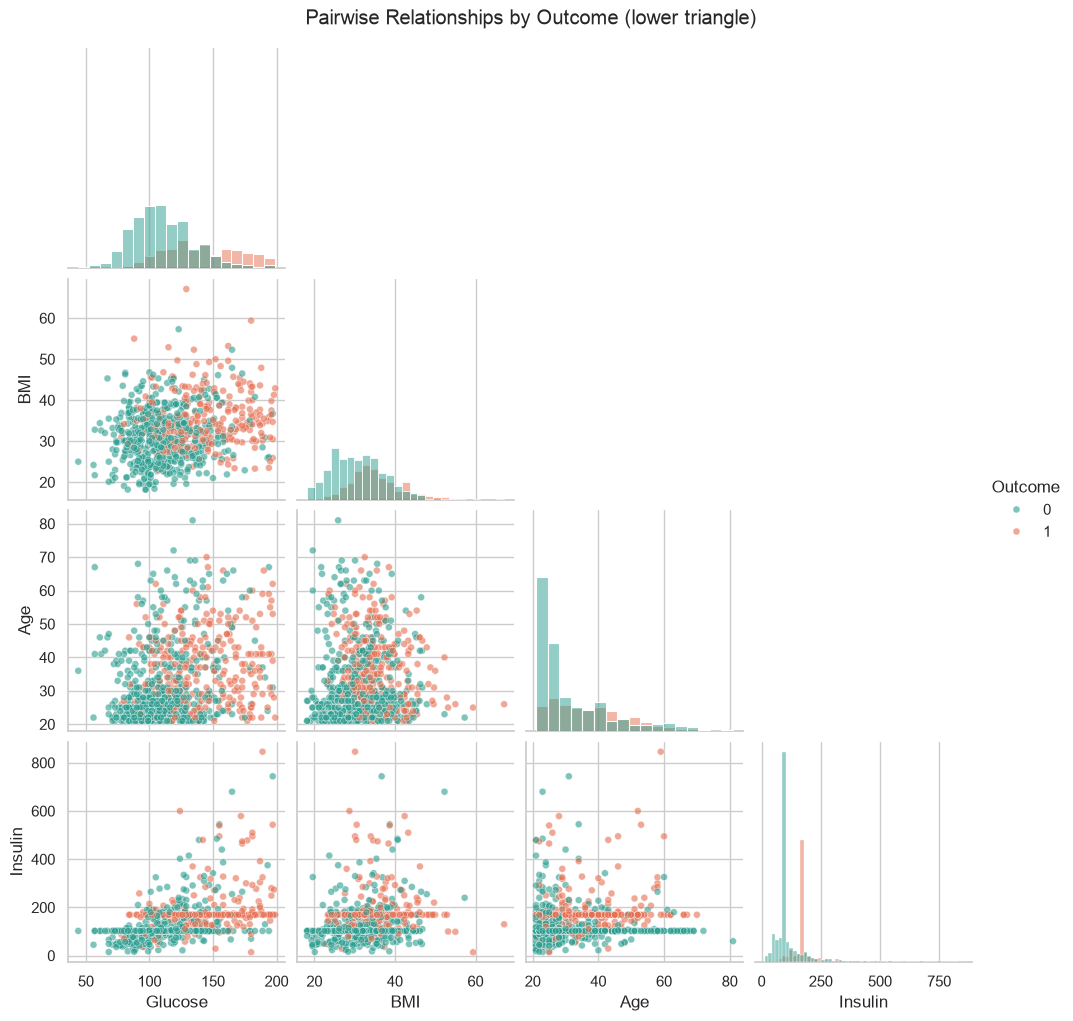

In [16]:
features_to_plot = ['Glucose', 'BMI', 'Age', 'Insulin', 'Outcome']

g = sns.pairplot(df[features_to_plot], hue='Outcome', corner=True,
                  palette={0: '#2a9d8f', 1: '#e76f51'}, diag_kind='hist',
                  plot_kws={'alpha': 0.6, 's': 25})
g.fig.suptitle('Pairwise Relationships by Outcome (lower triangle)', y=1.02)
plt.show()


### Distribution Shift by Outcome
- **Visualization:** Box-and-strip plots illustrating the distribution of key clinical measurements for both diabetic and non-diabetic groups.
- **Analytical Purpose:** These plots contrast the central tendencies and variances between the two classes, revealing the degree to which specific physiological measurements diverge based on the diabetes diagnosis.


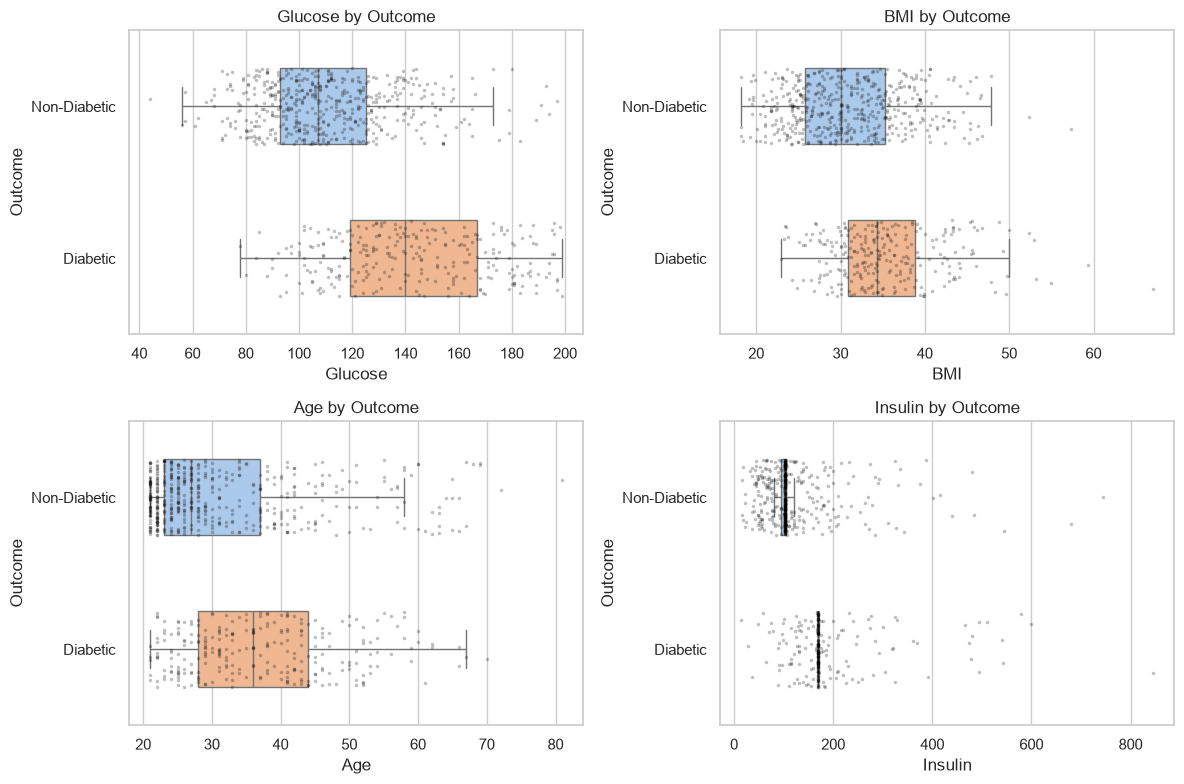

In [17]:
box_features = ['Glucose', 'BMI', 'Age', 'Insulin']
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for ax, feature in zip(axes, box_features):
    sns.boxplot(y='Outcome', x=feature, data=df, ax=ax, orient='h', hue='Outcome', palette='pastel', width=0.5, fliersize=0, legend=False, dodge=False)
    sns.stripplot(y='Outcome', x=feature, data=df, ax=ax, orient='h', color='black', alpha=0.25, size=2.5, jitter=0.25)
    ax.set_yticks([0, 1])
    ax.set_yticklabels(['Non-Diabetic', 'Diabetic'])
    ax.set_title(f'{feature} by Outcome')

plt.tight_layout()
plt.show()


### Class Distribution of the Target
- **Visualization:** A donut chart representing the proportion of instances in each outcome class.
- **Analytical Purpose:** This confirms the presence of class imbalance in the dataset, justifying the reliance on metrics such as the F1-score and Recall over standard Accuracy.


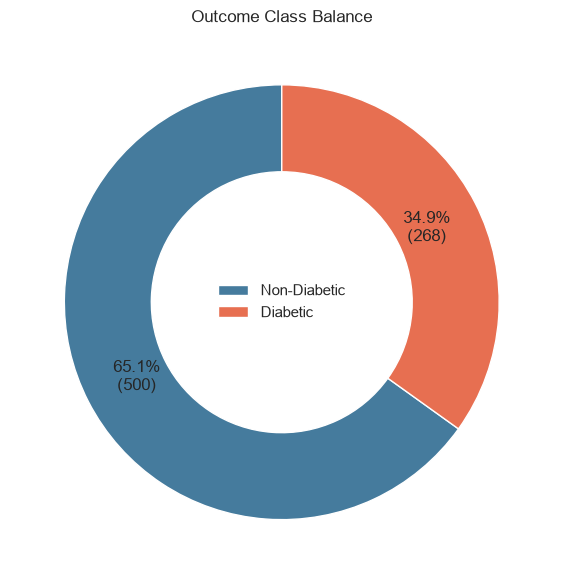

In [18]:
counts = df['Outcome'].value_counts().sort_index()
labels = ['Non-Diabetic', 'Diabetic']
colors = ['#457b9d', '#e76f51']

fig, ax = plt.subplots(figsize=(6, 6))
wedges, _, autotexts = ax.pie(
    counts, labels=None, colors=colors, autopct=lambda p: f'{p:.1f}%\n({int(round(p/100*counts.sum()))})',
    startangle=90, pctdistance=0.75, wedgeprops={'width': 0.4, 'edgecolor': 'white'}
)
ax.legend(wedges, labels, loc='center', frameon=False)
ax.set_title('Outcome Class Balance')
plt.tight_layout()
plt.show()


### Feature Distributions
- **Visualization:** Smoothed histograms with kernel density estimates for all input features.
- **Analytical Purpose:** Evaluating the skewness and general shape of feature distributions informs the necessity for preprocessing steps and helps validate the assumptions of certain statistical models.


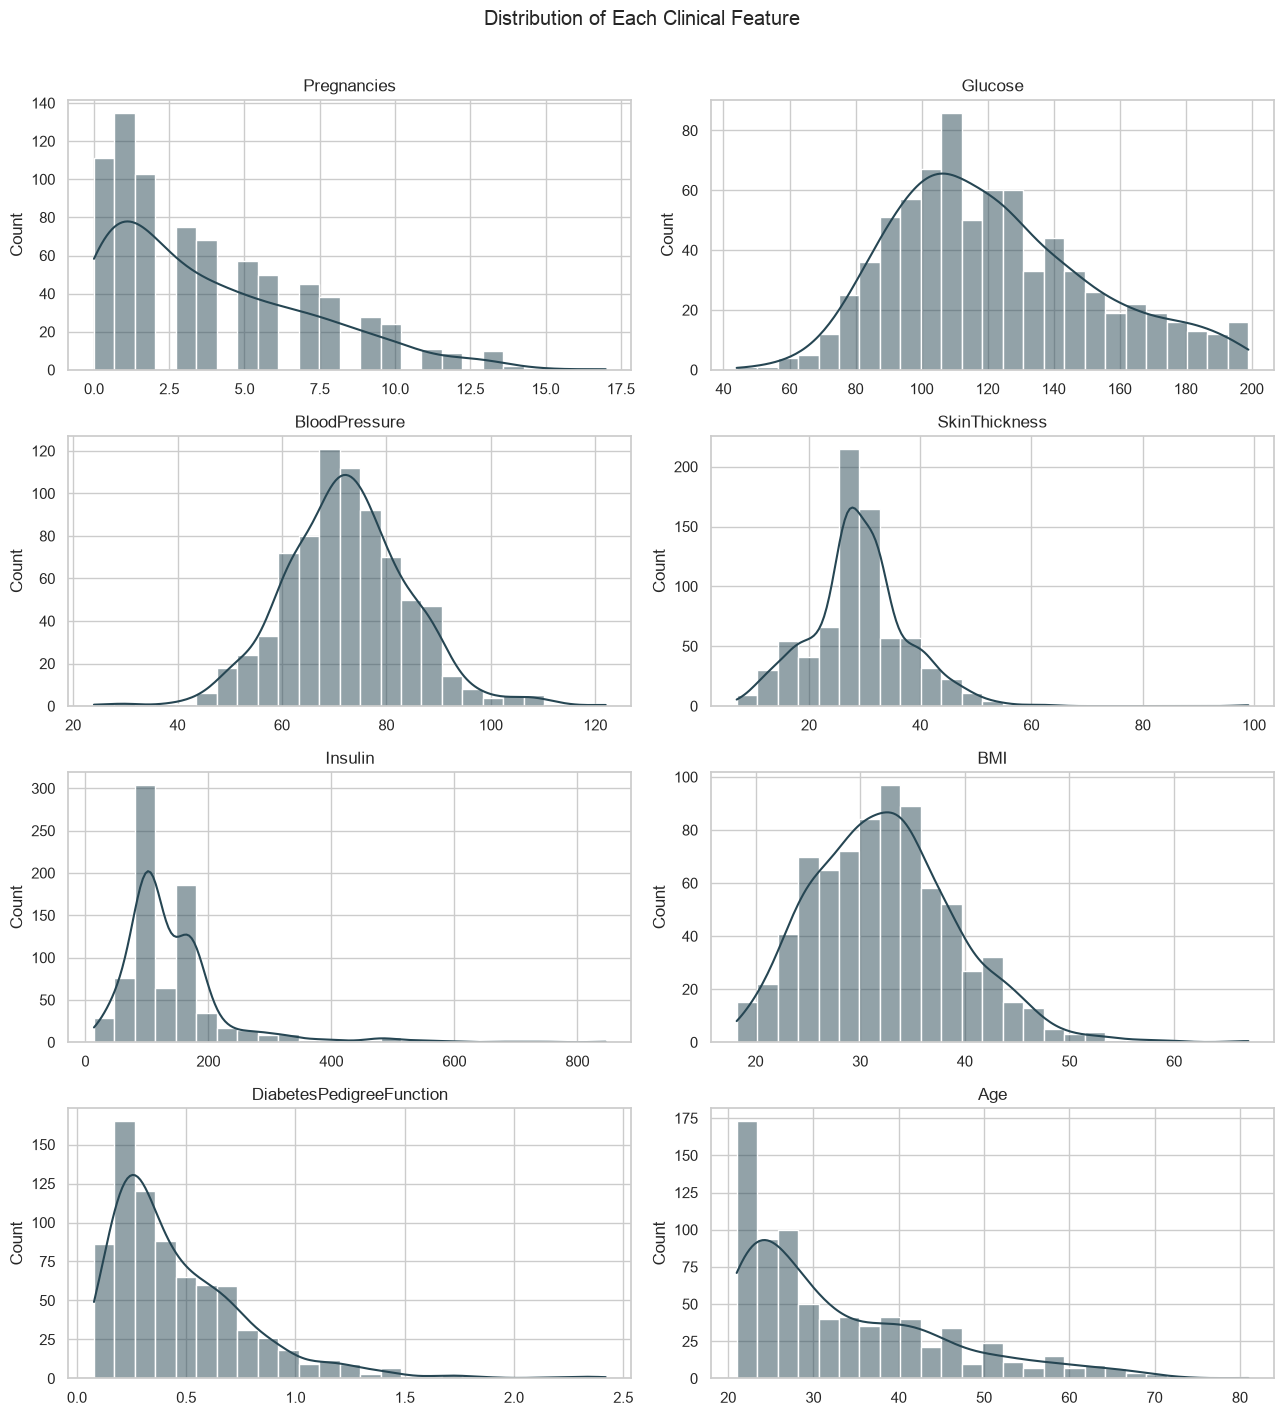

In [19]:
feature_cols = [c for c in df.columns if c != 'Outcome']
fig, axes = plt.subplots(4, 2, figsize=(13, 14))
axes = axes.flatten()

for ax, col in zip(axes, feature_cols):
    sns.histplot(df[col], bins=25, kde=True, color='#264653', ax=ax, edgecolor='white')
    ax.set_title(col)
    ax.set_xlabel('')

plt.suptitle('Distribution of Each Clinical Feature', y=1.01)
plt.tight_layout()
plt.show()


### Class-Conditional Feature Distributions
- **Visualization:** Violin plots for all features, partitioned by the target outcome.
- **Analytical Purpose:** By superimposing density estimates over summary statistics, this visualization captures asymmetric or multimodal distributions within each class, offering a more nuanced view than standard box plots.


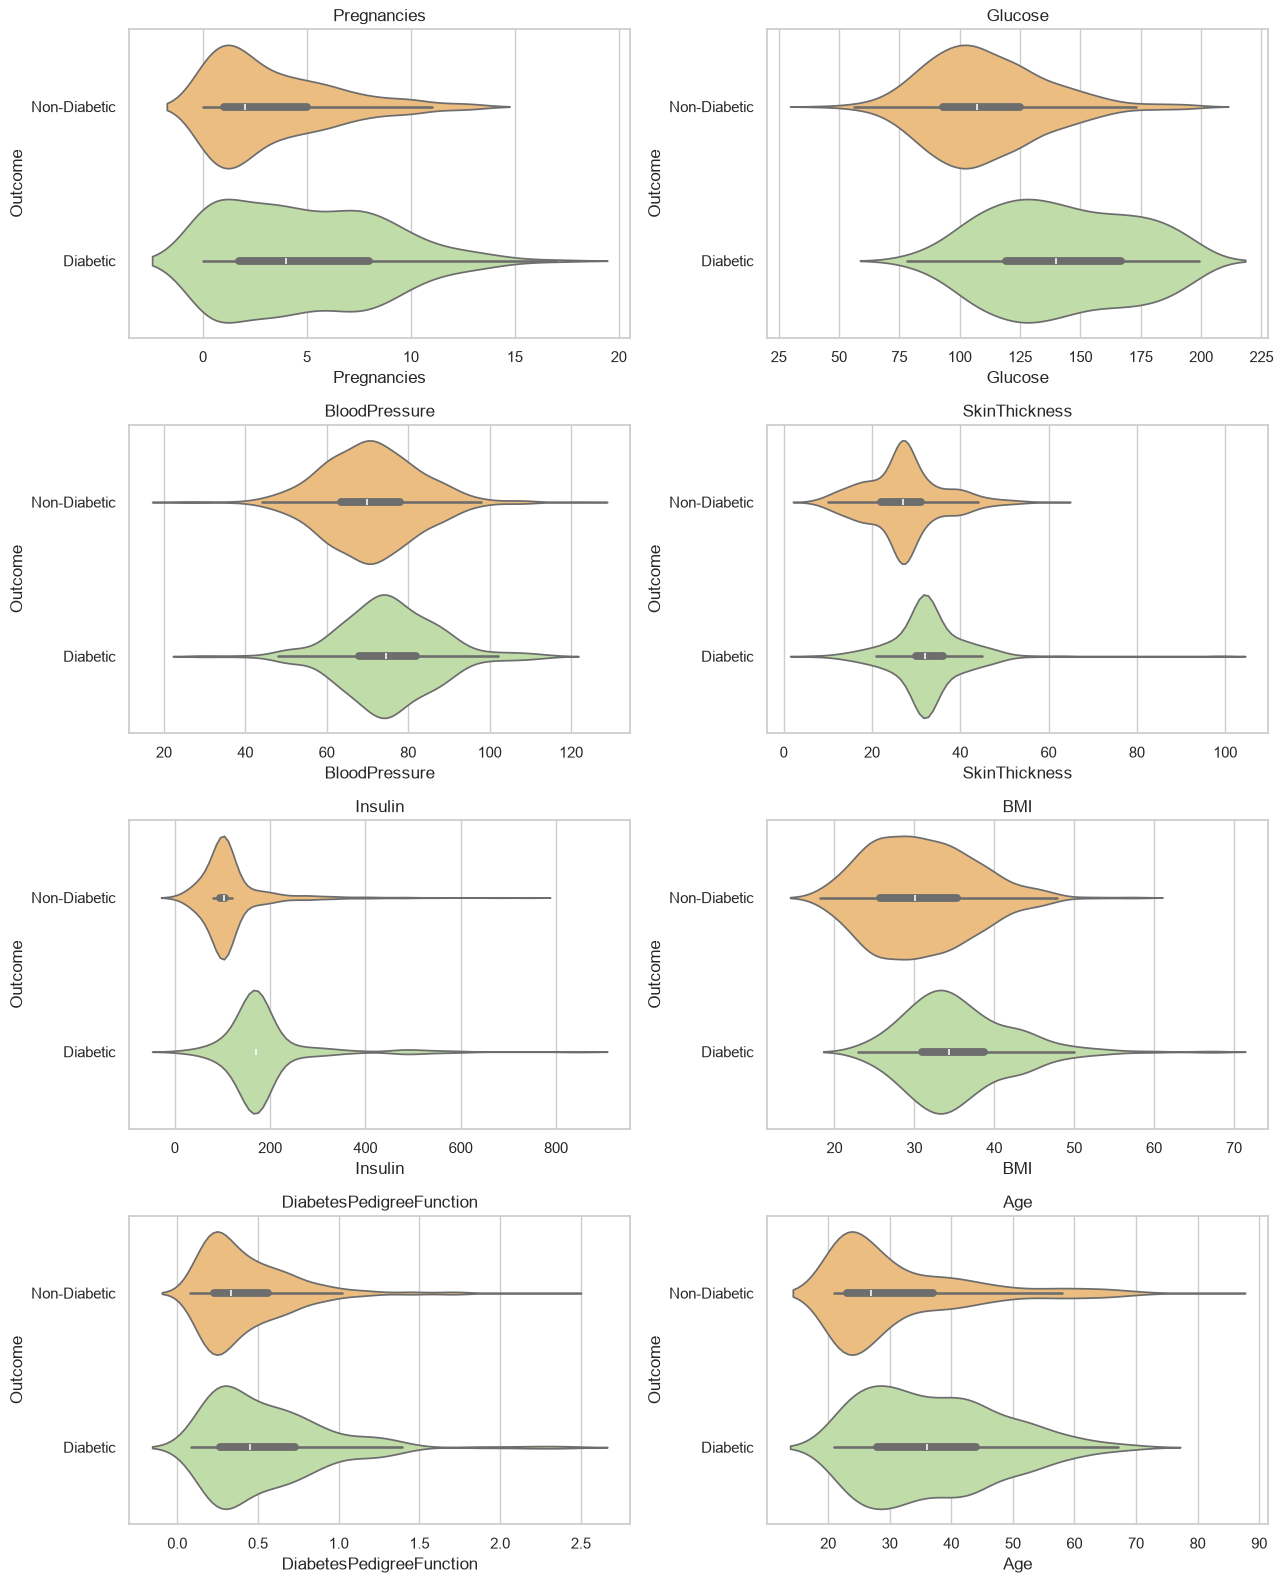

In [20]:
fig, axes = plt.subplots(4, 2, figsize=(13, 16))
axes = axes.flatten()

for ax, feature in zip(axes, feature_cols):
    sns.violinplot(y='Outcome', x=feature, data=df, ax=ax, orient='h', hue='Outcome', palette='Spectral', inner='box', legend=False, dodge=False)
    ax.set_yticks([0, 1])
    ax.set_yticklabels(['Non-Diabetic', 'Diabetic'])
    ax.set_title(feature)

plt.tight_layout()
plt.show()


### Joint Density of Principal Predictors
- **Visualization:** A bivariate kernel density contour plot mapping Glucose against BMI, color-coded by class outcome.
- **Analytical Purpose:** This analysis illustrates the joint probability density of the two most correlated predictors, highlighting regions of the feature space where the classes are most distinctly separable.


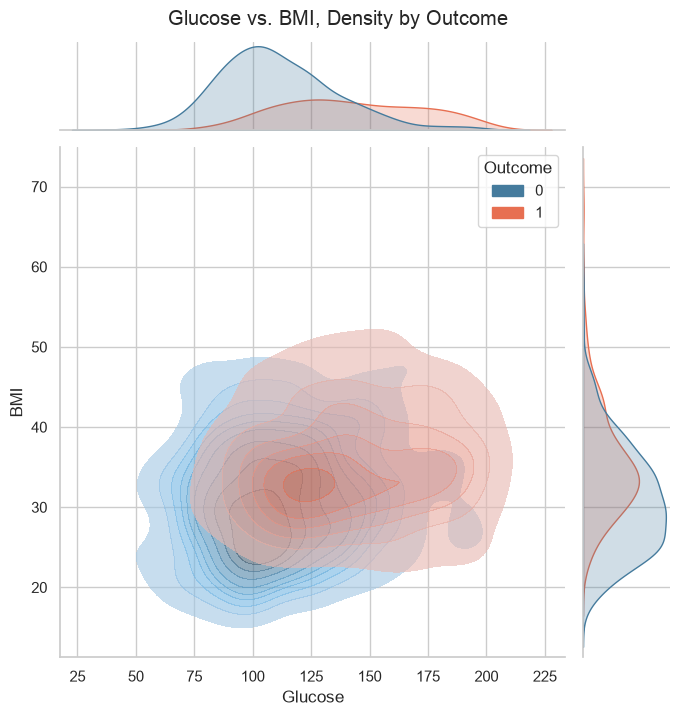

In [21]:
df_clean = df[(df['BMI'] > 0) & (df['Glucose'] > 0)]

g = sns.jointplot(x='Glucose', y='BMI', data=df_clean, hue='Outcome', kind='kde',
                   palette={0: '#457b9d', 1: '#e76f51'}, fill=True, alpha=0.6, height=7)
g.fig.suptitle('Glucose vs. BMI, Density by Outcome', y=1.02)
plt.show()


## Hyperparameter Sensitivity: k-NN

**Question.** How much does k-NN's performance actually depend on the neighborhood size `k` and the weighting scheme (`uniform` vs. `distance`)?

**Setup.** Using the cross-validation results already collected during the k-NN grid search, this section looks at how accuracy changes as `n_neighbors` varies over `{3, 5, 7, 9}` and `weights` switches between `uniform` and `distance`. This gives a sense of whether k-NN's performance here is fragile or fairly robust to these choices.

,k,weights,Mean CV Accuracy,Std
0,7,uniform,0.8192,0.0220
1,7,distance,0.8176,0.0223
2,9,uniform,0.8160,0.0160
3,9,distance,0.8160,0.0197
4,3,uniform,0.8062,0.0199
5,3,distance,0.8062,0.0199
6,5,distance,0.8062,0.0288
7,5,uniform,0.8046,0.0286


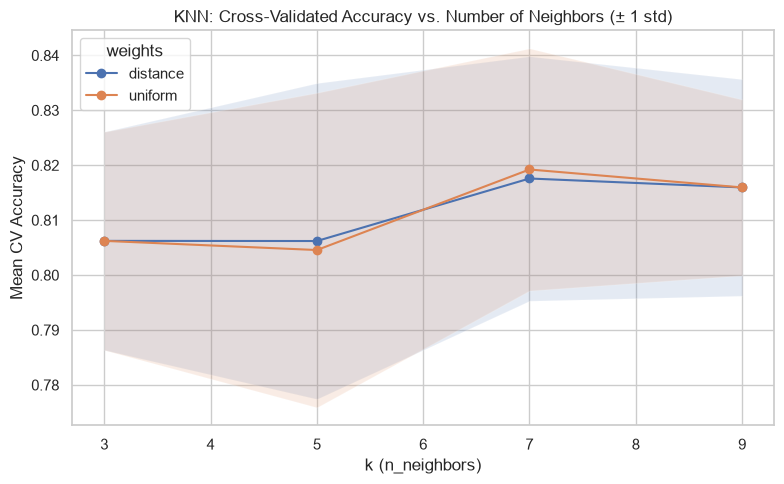

Best configuration: k=7, weights='uniform' -> CV accuracy = 0.8192
Spread across every k/weights combination tried: 0.0147 (small, so k is not a very sensitive hyperparameter here).


In [22]:
knn_cv_df = pd.DataFrame(grid_knn.cv_results_)[['param_n_neighbors', 'param_weights', 'mean_test_score', 'std_test_score']]
knn_cv_df.columns = ['k', 'weights', 'Mean CV Accuracy', 'Std']
knn_cv_df = knn_cv_df.sort_values('Mean CV Accuracy', ascending=False).reset_index(drop=True)
display(knn_cv_df.style.format({'Mean CV Accuracy': '{:.4f}', 'Std': '{:.4f}'}))

plt.figure(figsize=(8, 5))
for weight_scheme, group in knn_cv_df.groupby('weights'):
    group = group.sort_values('k')
    plt.plot(group['k'], group['Mean CV Accuracy'], marker='o', label=weight_scheme)
    plt.fill_between(group['k'],
                      group['Mean CV Accuracy'] - group['Std'],
                      group['Mean CV Accuracy'] + group['Std'], alpha=0.15)
plt.title('KNN: Cross-Validated Accuracy vs. Number of Neighbors (± 1 std)')
plt.xlabel('k (n_neighbors)')
plt.ylabel('Mean CV Accuracy')
plt.legend(title='weights')
plt.tight_layout()
plt.show()

print(f"Best configuration: k={grid_knn.best_params_['n_neighbors']}, weights='{grid_knn.best_params_['weights']}' "
      f"-> CV accuracy = {grid_knn.best_score_:.4f}")

spread = knn_cv_df['Mean CV Accuracy'].max() - knn_cv_df['Mean CV Accuracy'].min()
print(f"Spread across every k/weights combination tried: {spread:.4f} "
      f"({'small, so k is not a very sensitive hyperparameter here' if spread < 0.02 else 'noticeable, so k is worth tuning carefully here'}).")


# 9. Model Comparison

**Question.** Which model generalizes best on the held-out test set, taking Accuracy, Precision, Recall, and F1-score together rather than any single metric?

=== Model Comparison, ranked by F1 ===


,Model,Accuracy,Precision,Recall,F1
0,XGBoost,87.66%,0.818,0.833,0.826
1,Random Forest,86.36%,0.811,0.796,0.804
2,SVM (RBF),83.77%,0.754,0.796,0.775
3,KNN,80.52%,0.722,0.722,0.722
4,SVM (Linear),74.03%,0.630,0.630,0.630
5,Logistic Regression,70.78%,0.588,0.556,0.571
6,Baseline (Most Frequent),64.94%,0.000,0.000,0.000


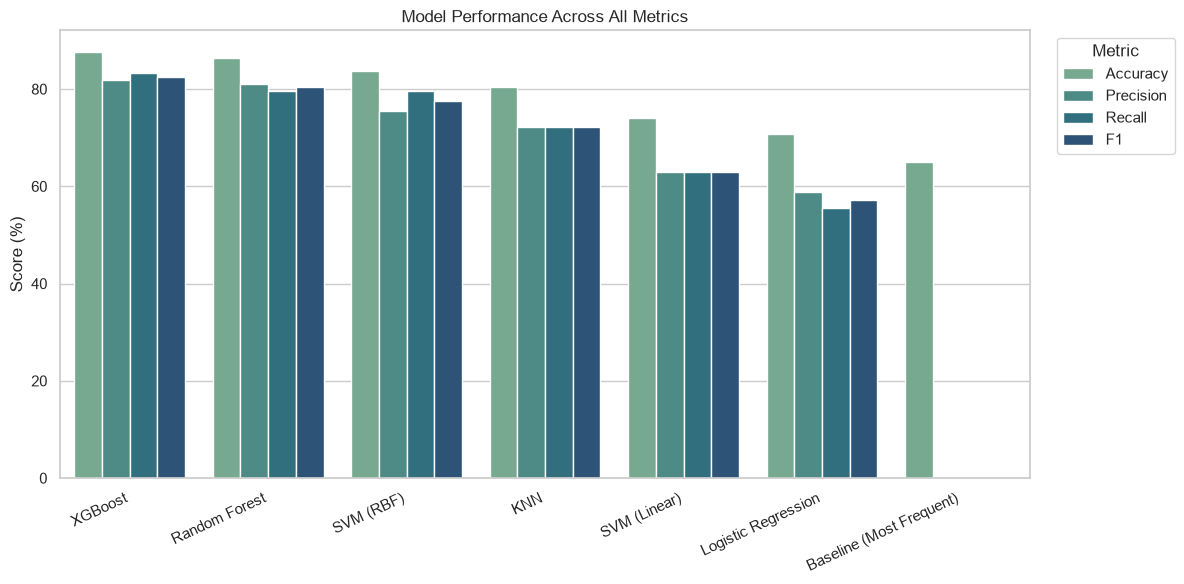

In [23]:
results_df = pd.DataFrame(model_metrics)
results_df_display = results_df.copy()
results_df_display['Accuracy'] = results_df_display['Accuracy'] * 100
results_df_display = results_df_display.sort_values(by='F1', ascending=False).reset_index(drop=True)

print("=== Model Comparison, ranked by F1 ===")
display(results_df_display.style.format({
    'Accuracy': '{:.2f}%', 'Precision': '{:.3f}', 'Recall': '{:.3f}', 'F1': '{:.3f}'
}))

metrics_long = results_df_display.melt(id_vars='Model', value_vars=['Accuracy', 'Precision', 'Recall', 'F1'],
                                        var_name='Metric', value_name='Score')
metrics_long.loc[metrics_long['Metric'] != 'Accuracy', 'Score'] *= 100

plt.figure(figsize=(12, 6))
ax = sns.barplot(data=metrics_long, x='Model', y='Score', hue='Metric', palette='crest')
plt.title('Model Performance Across All Metrics')
plt.ylabel('Score (%)')
plt.xlabel('')
plt.xticks(rotation=25, ha='right')
plt.legend(title='Metric', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


# 10. Representation Analysis

**Question.** Does standardizing the feature space actually make a measurable difference for a distance-based model like k-NN?

**Setup.** k-NN is trained once on the raw, unscaled features and once on the standardized features, and the two are compared directly. This is a direct illustration of how much the choice of representation shapes what a model can learn, independent of the algorithm itself.

KNN accuracy on raw (unscaled) features:   85.06%
KNN accuracy on standardized features:     81.17%


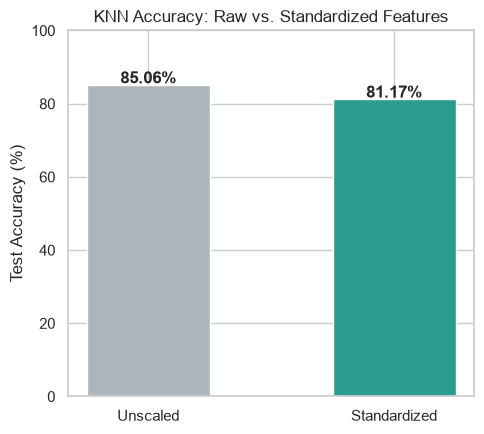


Takeaway: on this particular split, the unscaled features actually did slightly better (3.90 pts higher) than the standardized ones. That does not overturn the general rule that KNN is distance-based and therefore scale-sensitive — it just means this train/test split and value of k happen not to expose the gap. Standardization remains the safer default for any distance-based model, and is applied throughout the rest of this notebook.


In [24]:
from sklearn.neighbors import KNeighborsClassifier

knn_unscaled = KNeighborsClassifier(n_neighbors=5)
knn_unscaled.fit(X_train, y_train)
acc_unscaled = accuracy_score(y_test, knn_unscaled.predict(X_test))

knn_scaled = KNeighborsClassifier(n_neighbors=5)
knn_scaled.fit(X_train_scaled, y_train)
acc_scaled = accuracy_score(y_test, knn_scaled.predict(X_test_scaled))

print(f'KNN accuracy on raw (unscaled) features:   {acc_unscaled*100:.2f}%')
print(f'KNN accuracy on standardized features:     {acc_scaled*100:.2f}%')

comparison = pd.DataFrame({'Representation': ['Unscaled', 'Standardized'],
                            'Accuracy': [acc_unscaled * 100, acc_scaled * 100]})
plt.figure(figsize=(5, 4.5))
bars = plt.bar(comparison['Representation'], comparison['Accuracy'], color=['#adb5bd', '#2a9d8f'], width=0.5)
for bar, val in zip(bars, comparison['Accuracy']):
    plt.text(bar.get_x() + bar.get_width() / 2, val + 0.5, f'{val:.2f}%', ha='center', fontweight='bold')
plt.ylim(0, 100)
plt.ylabel('Test Accuracy (%)')
plt.title('KNN Accuracy: Raw vs. Standardized Features')
plt.tight_layout()
plt.show()

gap = acc_scaled - acc_unscaled
if gap > 0.005:
    verdict = (f"standardizing helped here (+{gap*100:.2f} pts) — features with naturally large ranges "
               "like Insulin would otherwise dominate the distance calculation.")
elif gap < -0.005:
    verdict = (f"on this particular split, the unscaled features actually did slightly better "
               f"({-gap*100:.2f} pts higher) than the standardized ones. That does not overturn the general "
               "rule that KNN is distance-based and therefore scale-sensitive — it just means this train/test "
               "split and value of k happen not to expose the gap. Standardization remains the safer default "
               "for any distance-based model, and is applied throughout the rest of this notebook.")
else:
    verdict = "the two representations performed almost identically on this particular split."
print(f'\nTakeaway: {verdict}')


## Final Model Selection

The final model is chosen programmatically from the comparison table: whichever classifier has the highest F1-score on the test set is selected for the demo application. The baseline is excluded from this selection, since it exists only to set a performance floor.

In [25]:
candidates_df = results_df_display[results_df_display['Model'] != 'Baseline (Most Frequent)']
best_row = candidates_df.sort_values('F1', ascending=False).iloc[0]
best_model_name = best_row['Model']
best_model_file = model_filenames[best_model_name]
final_model_needs_scaling = model_needs_scaling[best_model_name]
final_model = joblib.load(best_model_file)

print(f"Selected final model: {best_model_name}")
print(f"  -> Serialized as: {best_model_file}")
print(f"  -> Accuracy={best_row['Accuracy']:.2f}%, Precision={best_row['Precision']:.3f}, "
      f"Recall={best_row['Recall']:.3f}, F1={best_row['F1']:.3f}")
print("Selection rule: highest F1 on the held-out test set among the trained models "
      "(F1 balances Precision and Recall, which fits this imbalanced medical-screening task well).")


Selected final model: XGBoost
  -> Serialized as: xgboost.pkl
  -> Accuracy=87.66%, Precision=0.818, Recall=0.833, F1=0.826
Selection rule: highest F1 on the held-out test set among the trained models (F1 balances Precision and Recall, which fits this imbalanced medical-screening task well).


# 11. Intelligent Application

To show the trained model working outside this report, the best-performing classifier (see Section 9) is packaged into a small full-stack demo application: a backend that loads the serialized model and preprocessing objects, and a React frontend for entering patient data and viewing the result.

The four screenshots below walk through one full prediction made in the running application, following this pipeline step by step from raw input to explanation.

**1. Patient intake.** A clinician (or patient) enters the eight clinical measurements. The form starts pre-filled with a sample profile that can be edited before running the assessment.

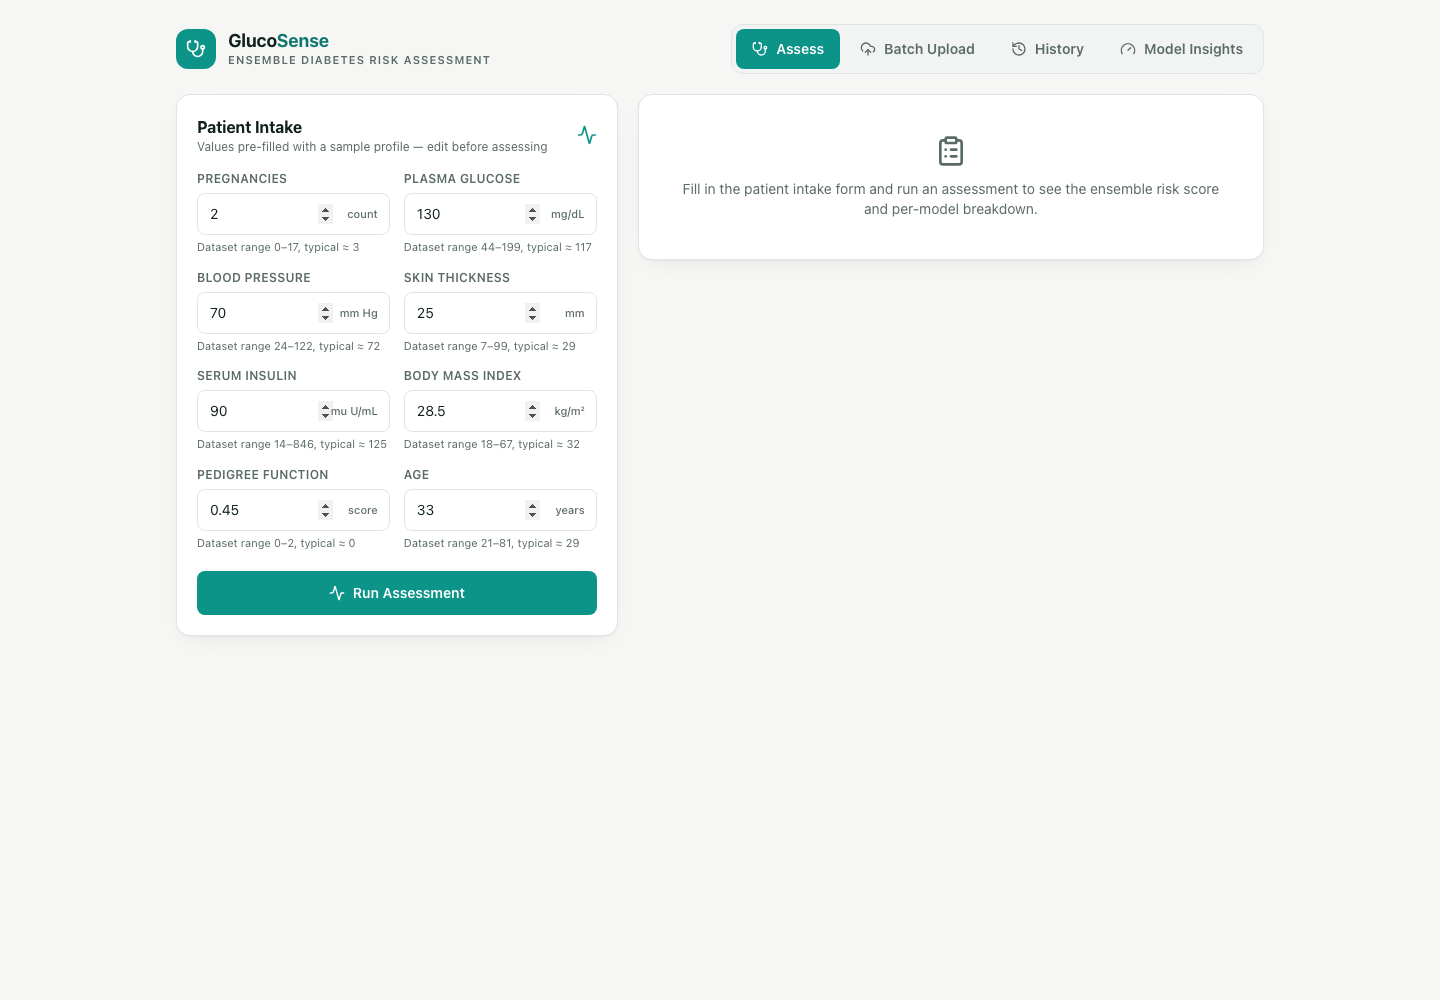
*Figure 1. Patient intake form, pre-filled with a sample profile.*

**2. Prediction result.** Submitting the form sends the feature vector through the same preprocessing pipeline used during training (imputation, then scaling) before it reaches the model. The app returns a diabetic risk score, a binary classification, and how many of the six trained models agreed on it — here, a 33.9% risk score, classified Non-Diabetic, with 83% ensemble agreement.

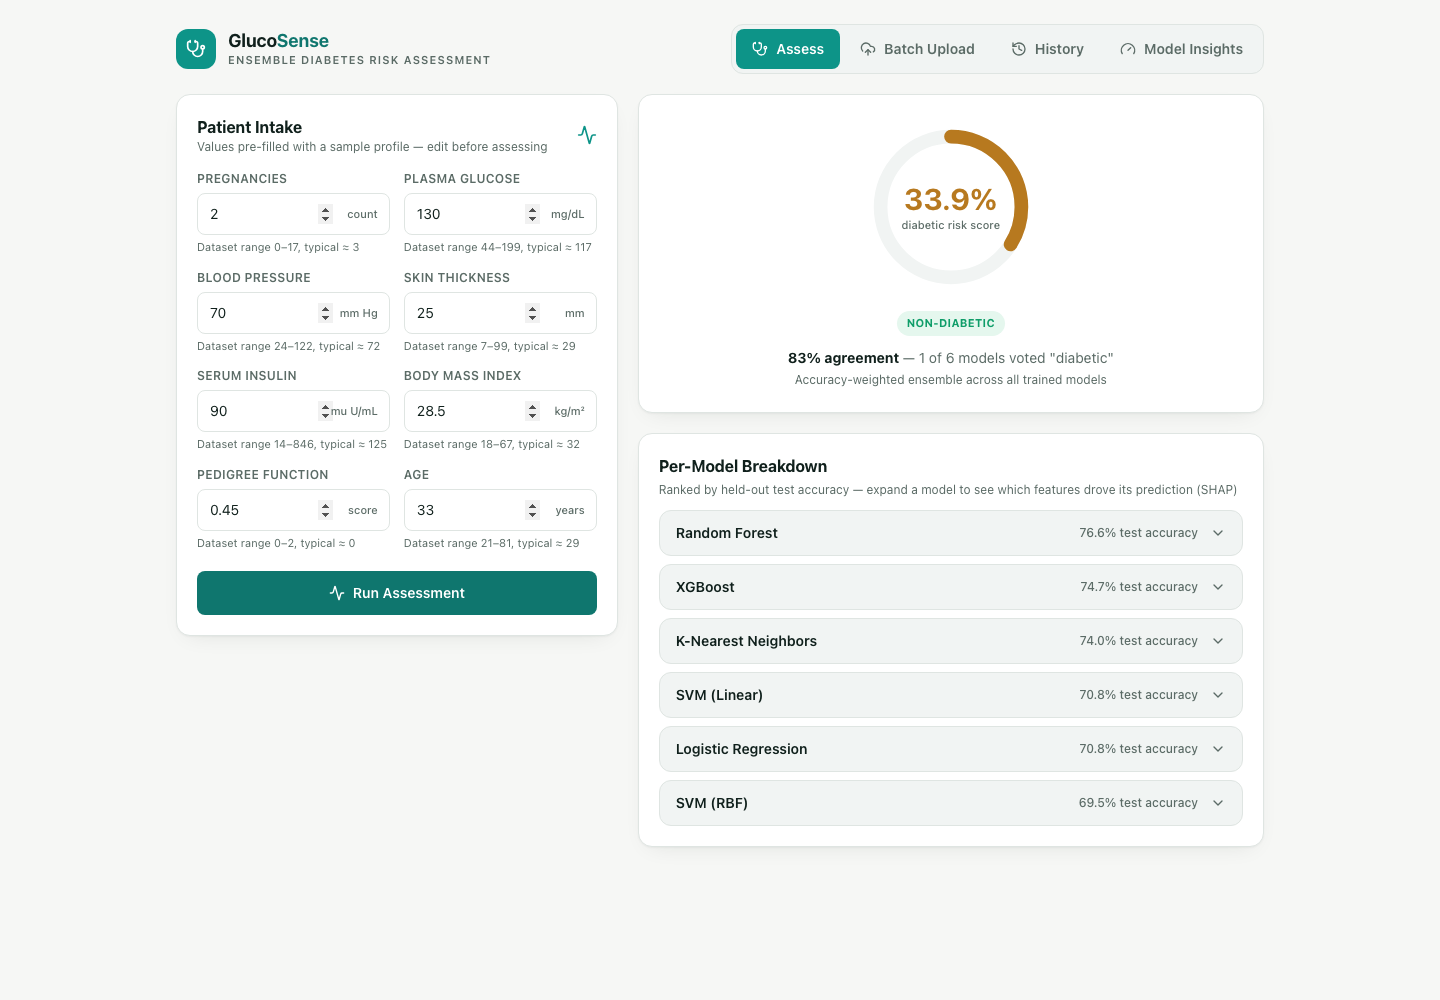
*Figure 2. Ensemble risk score and classification returned for the submitted profile.*

**3. Per-model breakdown.** Each model in the ensemble can be expanded individually. Expanding Random Forest shows a SHAP-based explanation of which features pushed its prediction toward or away from "diabetic" for this specific patient — Age, Glucose, and BloodPressure pushed the score up, while BMI and Insulin pulled it down.

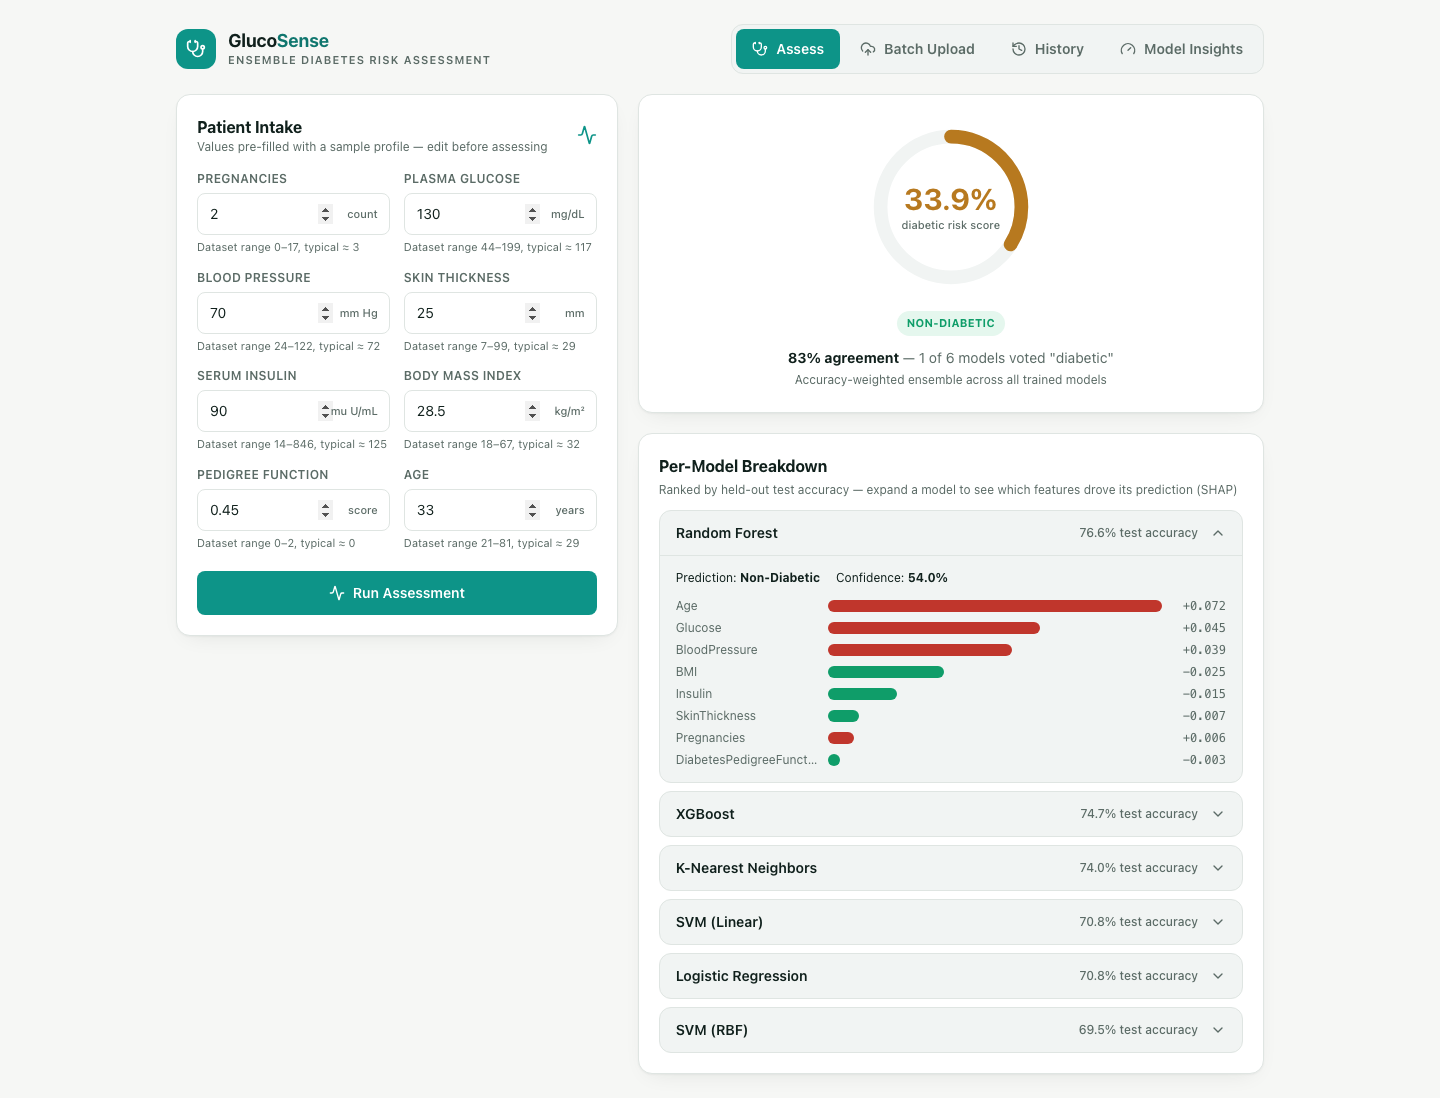
*Figure 3. Per-model results with a SHAP feature-contribution breakdown for Random Forest.*

**4. Model insights dashboard.** A separate view aggregates results across the whole test set: a side-by-side comparison of Accuracy/Precision/Recall/F1 for all six models, global feature importance from the Random Forest, and the confusion matrix for every model. This is the same information reported in Sections 8–9, surfaced inside the application itself rather than only in this report.

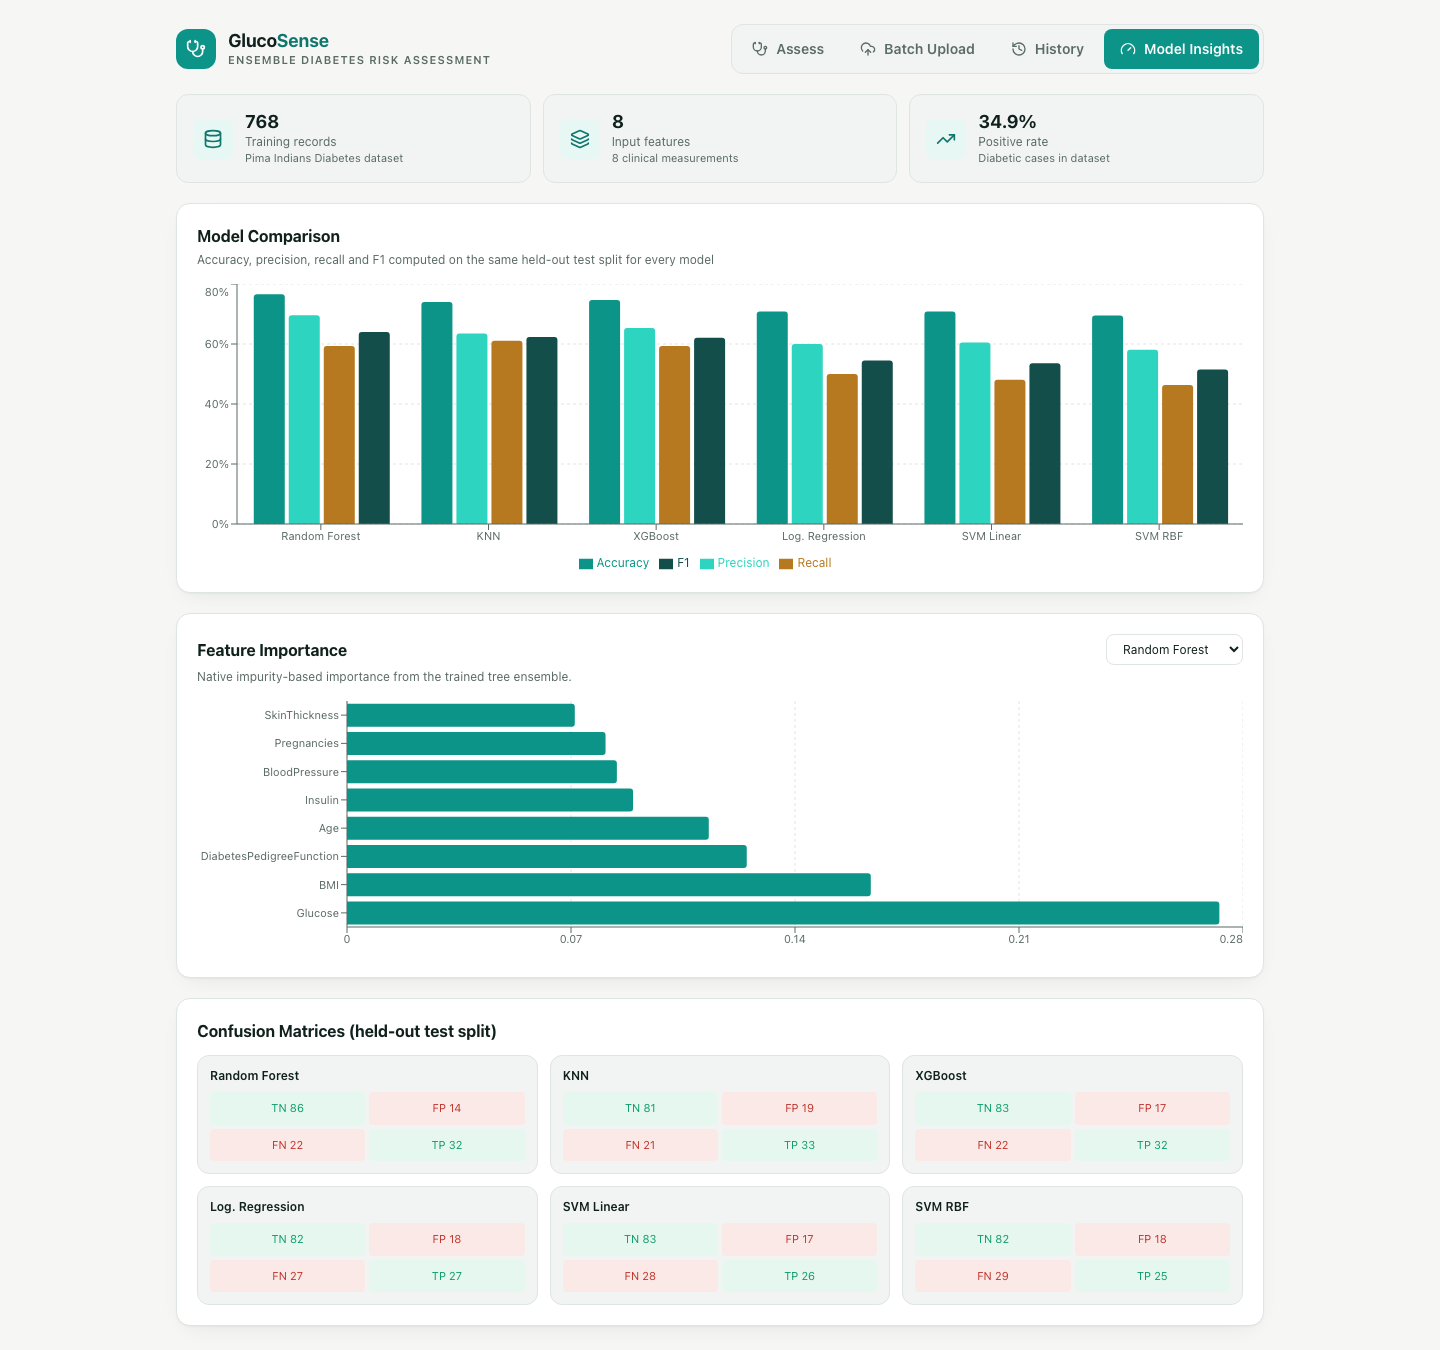
*Figure 4. Model comparison, feature importance, and confusion matrices, aggregated across the test set.*

# 12. Limitations

The system shows real predictive ability, but it isn't ready to be used as a standalone clinical tool. A few limitations are worth being upfront about:

- **Population bias.** The training data comes only from female patients of Pima Indian heritage, so the learned decision boundary may not transfer well to patients with different demographics or physiology.
- **No sense of time.** Each feature vector is a single snapshot of a patient's health. The system has no way to account for how a patient's condition is changing over time.
- **Imputation is a simplification.** Replacing invalid zero readings with the training median is a reasonable default, but it can understate the real uncertainty in incomplete clinical data and slightly flattens feature variance.
- **Small dataset.** With only 768 records, the reported metrics carry a fair amount of sampling variance and should be read as estimates, not guarantees of real-world performance.
- **Screening tool, not a diagnosis.** This system is meant to support an initial triage decision. Its output is a probability estimate, not a medical diagnosis, and should always be combined with clinical judgment.

# 13. Reflection

Even though it's built from classical ML rather than anything fancier, this system does show the basic ingredients of an intelligent system: it turns raw environmental data into a structured representation, finds statistical patterns in that representation through supervised learning, and uses those patterns to make decisions about new, unseen patients.

The 8-dimensional feature vector is a reasonable representation for this problem — it captures the relevant physiological measurements in a form that classical ML models can use directly. That said, a flat feature vector like this throws away any spatial or temporal structure that a richer form of medical data might have, such as imaging or a time series of visits. Representing that kind of data well would call for a different approach entirely — tensors for images, sequences for models like RNNs.

Running the same preprocessing, training, and evaluation pipeline across seven different models made it easy to compare them on equal footing, and the results made it clear just how much the combination of representation and algorithm matters — the same data produced fairly different performance depending on whether the model was linear, distance-based, or tree-based, and whether the features were scaled at all.

# 14. Conclusion

This assignment goes through the full process of building a classical machine learning system, from defining a real problem to shipping a working demo that uses the trained model. The results reinforce a point that's easy to underestimate: how the data is represented — in particular, whether distance-sensitive models get standardized input — has as much impact on performance as the choice of algorithm itself, and careful hyperparameter tuning is what turns a decent model into a reliably good one. Overall, the finished system is a working example of the core idea behind intelligent systems: taking raw environmental data, shaping it into a representation a model can learn from, and using that to make useful decisions.